In [1]:
import numpy as np 
# 1) Bit generation and PAM-4 mapping (Gray)
# Generate random bits: 2 rows (b1, b2), Nsym columns
Nsym = 10  # Example number of symbols
bits = np.random.randint(0, 2, Nsym * 2) 
print(bits)

[0 0 1 1 0 0 1 1 1 1 1 0 1 0 1 0 1 0 1 0]


In [2]:
import numpy as np 
# 1) Bit generation and PAM-4 mapping (Gray)
# Generate random bits: 2 rows (b1, b2), Nsym columns
Nsym = 10  # Example number of symbols
bits = np.random.randint(0, 2, (2, Nsym)) 
print(bits)

[[0 1 1 1 1 0 0 1 0 0]
 [0 0 0 1 1 0 1 1 0 1]]


In [4]:
    # 1) Bit generation and PAM-4 mapping (Gray)
    # Generate random bits: 2 rows (b1, b2), Nsym columns
    bits = np.random.randint(0, 2, (2, Nsym)) # b(1, :) are the MSBs AND b(2, :) are the LSBs
    pam4_levels = np.array([-3, -1, 3, 1])
    # generate the incides for mapping (00 -> idx0 -> -3, 01 -> idx1 -> -1, 11 -> idx3 -> 1, 10 -> idx2 -> 3)
    symbol_indices = 2 * bits[1, :] + bits[0, :]
    # Map to levels
    tx_symbols = pam4_levels[symbol_indices]
    print(tx_symbols)

[ 1 -1  3 -3  3 -3  1 -1  1 -1]


In [4]:
from channel import simulate_imdd_pam4_cd_pd

rx, tx = simulate_imdd_pam4_cd_pd(
    Nsym=20_000,
    SNRdB=25,
    Rsym=28e9,
    Ns=8,
    rolloff=0.2,
    span=10,
    L_km=20,
    D=16.7e-6,
    lam=1550e-9,
    seed=0
)

print(rx.shape, tx.shape)


(19990,) (19990,)


In [5]:
import numpy as np
print(np.unique(tx))


[-3 -1  1  3]


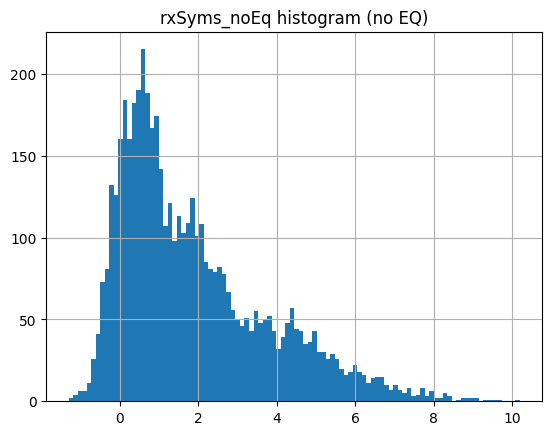

In [6]:
import matplotlib.pyplot as plt
plt.hist(rx[:5000], bins=100)
plt.title("rxSyms_noEq histogram (no EQ)")
plt.grid(True)
plt.show()


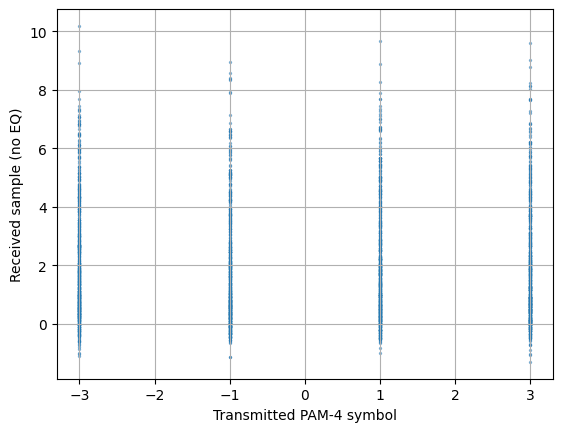

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(tx[:3000], rx[:3000], s=2, alpha=0.5)
plt.xlabel("Transmitted PAM-4 symbol")
plt.ylabel("Received sample (no EQ)")
plt.grid(True)
plt.show()


In [8]:
import numpy as np
data = np.load("dataset_pam4_cd_pd.npz")
print(np.unique(data["y_train"]))


[-3 -1  1  3]


In [9]:
print(np.isnan(data["X_train"]).any(), np.isnan(data["y_train"]).any())


False False
